#  Аналіз ринку ноутбуків на базі 3 магазинів (Foxtrot. Telemart. Brain)

# Підготовка даних

In [433]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

## Завантажуємо дані

In [434]:
foxtrot = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\foxtrot_data.csv")
brain = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\brain_data.csv")
telemart = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\telemart_data.csv")
cpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_cpu.csv")
gpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_gpu.csv")

In [435]:
foxtrot = pd.DataFrame(foxtrot)
brain = pd.DataFrame(brain)
telemart = pd.DataFrame(telemart)
cpurating = pd.DataFrame(cpu_rating)
gpurating = pd.DataFrame(gpu_rating)

## Чистка даних

#### Foxtrot

In [436]:
foxtrot["shop"] ="foxtrot"
foxtrot["product_code"] = foxtrot["product_code"].astype(int)
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    int64  
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           596 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 52.6 KB


In [437]:
cpulist = cpu_rating['full_name'].tolist()

def full_name(name: str):
    if not isinstance(name, str):
        return name
    name = name.strip()
    pattern = rf"\b{re.escape(name)}\b"
    for full_name in cpulist:
        if isinstance(full_name, str) and re.search(pattern, full_name):
            return full_name
    return name

In [438]:
foxtrot['cpu'] = foxtrot['cpu'].apply(full_name)
foxtrot.head()

,full_name,price,product_code,shop,product_url,cpu,gpu,other
0,ACER Aspire Lite AL15-45P-R88L Silver,29999.0,7196472,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-ac...,AMD Ryzen 7 5825U,Radeon Graphics,"{""Модельний ряд"": ""Acer Aspire Lite"", ""Тип"": ""..."
1,Ігровий ACER Nitro V 15 AI ANV15-42-R130 Obsid...,40999.0,7177448,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-ac...,AMD Ryzen 7 7445HS,NaN,"{""Тип"": ""ноутбук"", ""Конструкція"": ""Класична"", ..."
2,LENOVO LOQ 15ARP9 Luna Gray,38999.0,7198892,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-le...,AMD Ryzen 5 7235HS,NaN,"{""Тип"": ""ноутбук"", ""Конструкція"": ""Класична"", ..."
3,APPLE MacBook Neo 13' A18 Pro 8/512GB Indigo,39999.0,7251464,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-ap...,Apple A18 Pro,Apple A18 Graphics,"{""Операційна система"": ""Mac OS"", ""Конструкція""..."
4,ACER Aspire Lite AL16-54P-51BX,26999.0,7122172,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-ac...,Intel Core i5-1334U,Intel UHD Graphics,"{""Конструкція"": ""Класична"", ""Діагональ дисплея..."


#### Brain

In [439]:
brain.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     480 non-null    str    
 1   price         480 non-null    float64
 2   product_code  480 non-null    str    
 3   shop          480 non-null    str    
 4   product_url   480 non-null    str    
 5   cpu           480 non-null    str    
 6   gpu           480 non-null    str    
 7   other         480 non-null    str    
dtypes: float64(1), str(7)
memory usage: 30.1 KB


#### Telemart

In [440]:
telemart['shop'] = 'telemart'
telemart['product_code'] = telemart['product_code'].astype(int)
telemart.info()

<class 'pandas.DataFrame'>
RangeIndex: 741 entries, 0 to 740
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     741 non-null    str    
 1   price         741 non-null    float64
 2   product_code  741 non-null    int64  
 3   shop          741 non-null    str    
 4   product_url   741 non-null    str    
 5   cpu           741 non-null    str    
 6   gpu           741 non-null    str    
 7   other         741 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 46.4 KB


#### CPU & GPU

In [441]:
cpu_rating = cpu_rating.drop('name', axis=1)
gpu_rating = gpu_rating.drop('name', axis=1)

cpu_rating = cpu_rating[cpu_rating['full_name'].notna()]
gpurating = gpu_rating[gpu_rating['full_name'].notna()]

In [442]:
cpu_rating.info()

<class 'pandas.DataFrame'>
Index: 3539 entries, 0 to 3542
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rate         3539 non-null   int64  
 1   full_name    3539 non-null   str    
 2   device_type  3539 non-null   str    
 3   performance  3539 non-null   float64
 4   year         3539 non-null   int64  
 5   tdp          3530 non-null   float64
 6   cores        3539 non-null   int64  
 7   threads      3539 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 248.8 KB


### Створення універсального датафрейму

#### Універсальний датафрейм

In [443]:
all_shop = pd.concat([brain, telemart, foxtrot])
all_shop.sample(5)

,full_name,price,product_code,shop,product_url,cpu,gpu,other
553,HP 15-fd2026ua AI Moonlight Blue,47099.0,858183,telemart,https://telemart.ua/ua/products/hp-15-fd2026ua...,Intel Core Ultra 5 225U (1.5-4.8 ГГц),Intel Graphics,"{""Процесор"": ""Intel Core Ultra 5 225U (1.5-4.8..."
377,MSI Katana 15 HX Black,79899.0,858413,telemart,https://telemart.ua/ua/products/msi-katana-15-...,Intel Core i7-14650HX (2.2–5.2 ГГц),NVIDIA GeForce RTX 5060,"{""Процесор"": ""Intel Core i7-14650HX (2.2–5.2 Г..."
300,HP ZBook X G1i 16 Meteor Silver,155755.0,818116,telemart,https://telemart.ua/ua/products/hp-zbook-x-g1i...,Intel Core Ultra 9 285H (2.7–5.4 ГГц),NVIDIA RTX PRO 2000,"{""Процесор"": ""Intel Core Ultra 9 285H (2.7–5.4..."
16,ASUS TUF Gaming F17 FX707VJB-HX094,49999.0,U1134222,brain,https://brain.com.ua/ukr/Noutbuk_ASUS_TUF_Gami...,Intel Core 5 210H (2.2 - 4.8 ГГц),NVIDIA GeForce RTX 3050,"{""Серія (модельний ряд)"": ""ASUS TUF Gaming"", ""..."
677,HP EliteBook X Flip G1i,115055.0,7194886,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-hp...,Intel Core Ultra 7 258V,Intel Arc Graphics,"{""Діагональ дисплея"": ""14\"""", ""Частота оновлен..."


#### Чистка та стандартизація

In [444]:
laptop_rating = pd.merge(left=all_shop, right=cpu_rating, how="left", left_on="cpu", right_on="full_name", validate="m:1")
laptop_rating = pd.merge(left=laptop_rating, right=gpu_rating, how="left", left_on="gpu", right_on="full_name", suffixes=['_cpu', '_gpu'], validate="m:m")
laptop_rating = laptop_rating.rename(columns={
    'full_name':'gpu_name',
    'full_name_y':'cpu_name',
    'full_name_x': 'laptop_name'}
    )
laptop_rating[['rate_cpu', 'rate_gpu', 'cores', 'threads', 'year_cpu', 'year_gpu']] = laptop_rating[['rate_cpu', 'rate_gpu', 'cores', 'threads', 'year_cpu', 'year_gpu']].fillna(0).astype(int)
laptop_rating.sample(5)

,laptop_name,price,product_code,shop,product_url,cpu,gpu,other,rate_cpu,cpu_name,...,tdp_cpu,cores,threads,rate_gpu,gpu_name,device_type_gpu,performance_gpu,year_gpu,tdp_gpu,architecture
468,GIGABYTE Aorus Elite 16,116999.0,U1121156,brain,https://brain.com.ua/ukr/Noutbuk_GIGABYTE_Aoru...,Intel Core Ultra 9 275HX (2.1 - 5.4 ГГц),NVIDIA GeForce RTX 5070,"{""Серія (модельний ряд)"": ""Gigabyte AORUS"", ""Т...",0,NaN,...,NaN,0,0,21,NVIDIA GeForce RTX 5070,desktop,68.83,2025,250.0,Blackwell 2.0
600,Acer Predator Helios 18 AI PH18-73 Abyssal Black,193999.0,769059,telemart,https://telemart.ua/ua/products/acer-predator-...,Intel Core Ultra 9 275HX (2.7-5.4 ГГц),NVIDIA GeForce RTX 5080,"{""Процесор"": ""Intel Core Ultra 9 275HX (2.7-5....",0,NaN,...,NaN,0,0,6,NVIDIA GeForce RTX 5080,desktop,85.44,2025,360.0,Blackwell 2.0
3705,HP ProBook 4 G1i 16 AI Pike Silver,79999.0,7203934,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-hp...,Intel Core Ultra 5 225H,Intel Arc Graphics,"{""Версія Windows"": ""Pro"", ""Конструкція"": ""Клас...",486,Intel Core Ultra 5 225H,...,28.0,14,14,0,NaN,NaN,NaN,0,NaN,NaN
3418,HP ProBook 4-G1i Pike Silver,77599.0,7203929,foxtrot,https://www.foxtrot.com.ua/uk/shop/noutbuki-hp...,Intel Core Ultra 5 225H,Intel Arc Graphics,"{""Версія Windows"": ""Pro"", ""Конструкція"": ""Клас...",486,Intel Core Ultra 5 225H,...,28.0,14,14,0,NaN,NaN,NaN,0,NaN,NaN
790,HP ZBook Fury G1i 18 Meteor Silver,198199.0,818107,telemart,https://telemart.ua/ua/products/hp-zbook-fury-...,Intel Core Ultra 7 255HX (1.8-5.2 ГГц),NVIDIA RTX PRO 3000,"{""Процесор"": ""Intel Core Ultra 7 255HX (1.8-5....",0,NaN,...,NaN,0,0,0,NaN,NaN,NaN,0,NaN,NaN


In [445]:
all_shop['cpu'] = all_shop['cpu'].str.replace(r"\s\(.*?\)", "", regex=True).str.strip()
all_shop['cpu'].sample(3)

682    Intel Core Ultra 7 255H
350          AMD Ryzen 5 7520U
176            AMD Ryzen 7 260
Name: cpu, dtype: str

### Функція для отримання додактової характеристики

In [446]:
import  ast

def get_spec(string: str, key: str) -> str | None:
    try:
        d = ast.literal_eval(string)
        return d.get(key)
    except:
        return None

# Аналіз даних

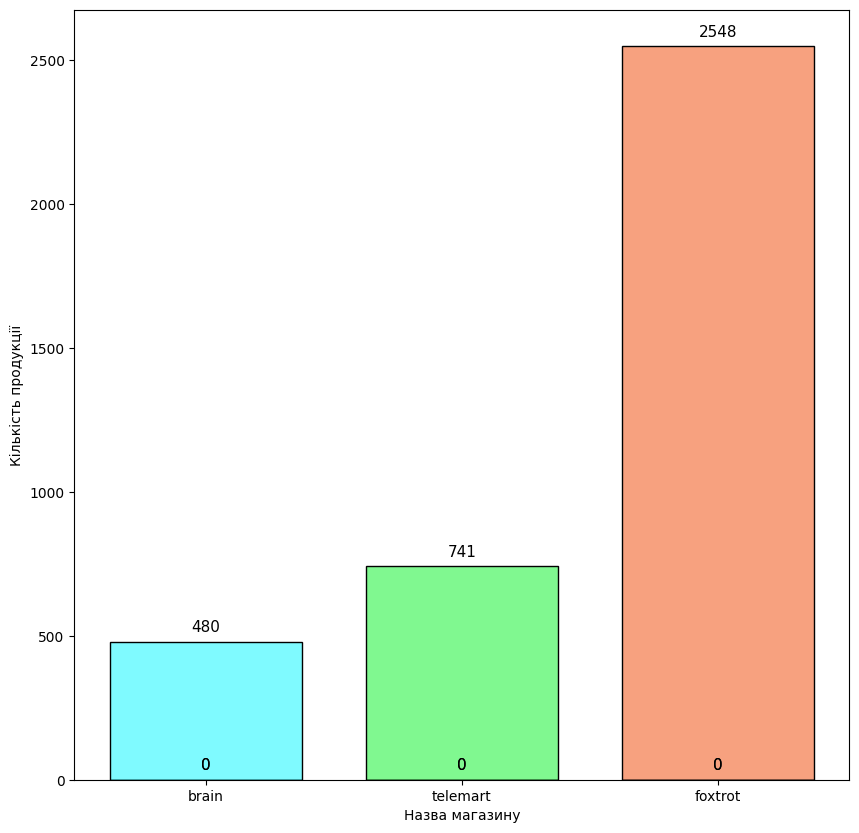

In [ ]:
palette = ["#01F7FF", "#03F323", "#F14501"]

plt.figure(figsize=[10, 10])
ax = sns.histplot(
    x='shop', 
    data=laptop_rating, 
    hue='shop',
    shrink=0.75,
    palette=palette,
    edgecolor='black',
    legend=False, 
    cbar=True
)
for container in ax.containers:
    ax.bar_label(container, fontsize=11, padding=5, 
                 label_type='edge', fmt='%d')
plt.xlabel("Назва магазину")
plt.ylabel("Кількість продукції")
plt.show()